In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("car data.csv")

Understand the Dataset

In [2]:
print(df.head())

print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         ---------

In [3]:
# Check Missing Values
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


Data Visualization

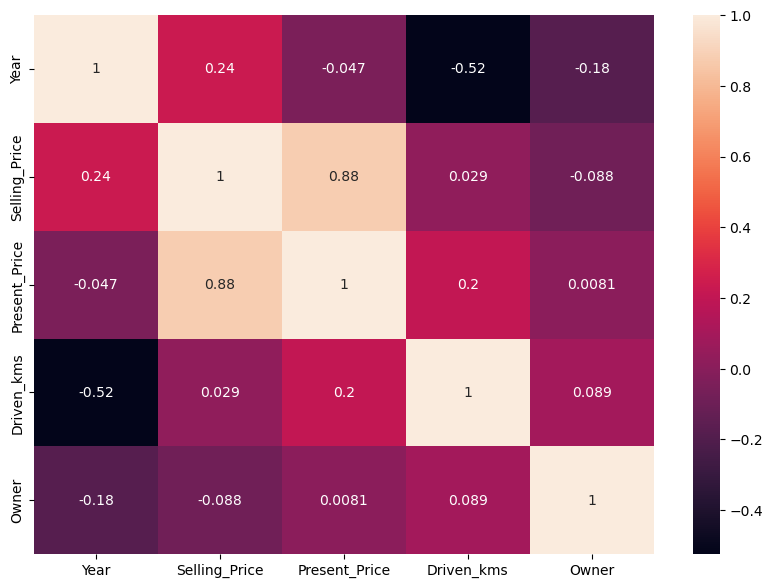

In [4]:
# Correlation Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

In [5]:
# Remove Unnecessary Column
df = df.drop('Car_Name', axis=1)

Convert Text Data to Numbers

In [6]:
# Use One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [7]:
# Train-Test Split
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Linear Regression

In [8]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Make Predictions
predictions = model.predict(X_test)

print(predictions)

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757  9.11623744  0.58602147
  8.4171901   3.42182892  6.90176412  3.05018044  0.4861294  10.7066932
  1.74950537  2.34321858  0.3983127   8.11856504  6.62720292  2.66249362
  0.78244173  3.69502798  5.24822431  2.82925881  2.13370568  1.75038508
  0.39804532  9.11715068 -0.65878346  2.29562782  8.5693085   4.49098276
  7.20461351  7.54096855  2.89153082  7.9380318   3.94218138  4.27826846
  4.33243831  0.60013063  7.34017047  0.47635371  7.29115924 11.23338227
  3.1391956   5.38488332  6.80049399  2.1763552  20.63141992 16.99979702
  7.50636179  9.6950184   4.47468976  8.97255903  1.82948926  7.6037684
  0.2226926 ]


In [10]:
# model evaluation 
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: 0.8488707839189292


R² Score

| Score | Meaning            |
| ----- | ------------------ |
| 1.0   | perfect prediction |
| 0.9   | excellent          |
| 0.7   | good               |
| 0.5   | average            |


In [11]:
import joblib

joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

Custom Prediction Example

In [12]:
print(X.columns)


Index(['Year', 'Present_Price', 'Driven_kms', 'Owner', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')


Custom Prediction Example

In [13]:
sample = pd.DataFrame([{
    'Year': 2018,
    'Present_Price': 5.5,
    'Driven_kms': 35000,
    'Owner': 0,
    'Fuel_Type_Diesel': 0,
    'Fuel_Type_Petrol': 1,
    'Selling_type_Individual': 1,
    'Transmission_Manual': 1
}])

result = model.predict(sample)

print(result)
print("Predicted Car Price:", result[0], "Lakhs")

[4.0674359]
Predicted Car Price: 4.067435903530168 Lakhs


visualization comparing actual vs predicted prices.

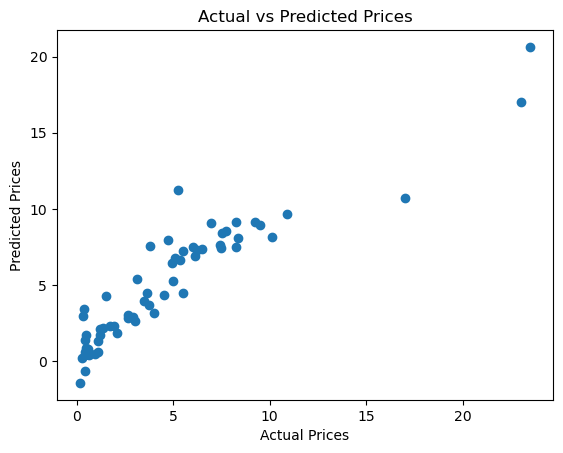

In [14]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()